In [65]:
import pandas as pd
import pathlib
import rootutils
import torch
import tqdm
import numpy as np
import seaborn as sns

rootutils.setup_root(".", indicator=".project-root", pythonpath=True)
root = pathlib.Path(rootutils.find_root("."))

from torch.nn import functional as F
from matplotlib import pyplot as plt

from src.core.data.sounding_out_chorus import SoundingOutChorus
from src.core.data.soundscape_embeddings import SoundscapeEmbeddingsDataModule
from src.core.transforms.translation import translation_1d as translation
from src.core.models.sivae import SIVAE
from src.core.models.vae import VAE
from src.core.models.mil_species_detector import MILSpeciesDetector
from src.core.utils.sketch import make_ax_invisible

plt.rcParams.update({
    'axes.labelsize': 9,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'axes.titlesize': 8, 
    'figure.titlesize': 10,
})

def wrap_sentence(sentence, max_length):
    words = sentence.split()
    lines = []
    current_line = ""
    for word in words:
        if len(current_line) + len(word) + (1 if current_line else 0) <= max_length:
            if current_line:
                current_line += " " 
            current_line += word
        else:
            if current_line:
                lines.append(current_line)
            current_line = word
    if current_line:
        lines.append(current_line)
    return "\n".join(lines)


model_path = pathlib.Path("/its/home/kag25/models/v4")
data = SoundingOutChorus("/its/home/kag25/data/sounding_out")
save_dir = pathlib.Path("/its/home/kag25/experiments/v4/plots")
save_dir.mkdir(exist_ok=True, parents=True)

In [3]:
model_class = "vae"
vae_model_name = "lumpy-gibson"
clf_model_name = "rich-state"
vae = VAE.load_from_checkpoint(model_path / model_class / vae_model_name / "step=180000.ckpt", map_location="cuda").eval()
vae_clf = MILSpeciesDetector.load_from_checkpoint(model_path / "species_detectors" / f"{vae_model_name}_SO_UK.ckpt", map_location="cuda").eval()
vae_scores = pd.read_parquet(f"/its/home/kag25/experiments/v4/species_detectors/test_scores.parquet/model_{vae_model_name}_run_id={clf_model_name}.parquet")
vae_scores.head()

/its/home/kag25/projects/ecolistening/interpretable_bioacoustic_classifiers/.venv/lib/python3.10/site-packages/lightning/fabric/utilities/cloud_io.py:57: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental

,species_name,AP,auROC,train_label_counts,run_id,model,scope,seed,attention,classifiers,clf_regulariser,attn_regulariser,beta,gamma_clf,gamma_attn,label_smoothing,clf_learning_rate,attn_learning_rate
0,Corvus monedula_Eurasian Jackdaw,0.175447,0.736986,116,rich-state,lumpy-gibson,SO_UK,8,None,None,None,None,0.0,0.001,0.001,0.0,0.03,0.0005
1,Corvus corone_Carrion Crow,0.401194,0.762382,140,rich-state,lumpy-gibson,SO_UK,8,None,None,None,None,0.0,0.001,0.001,0.0,0.03,0.0005
2,Aythya collaris_Ring-necked Duck,0.325552,0.734833,113,rich-state,lumpy-gibson,SO_UK,8,None,None,None,None,0.0,0.001,0.001,0.0,0.03,0.0005
3,Sturnus vulgaris_European Starling,0.111765,0.892060,12,rich-state,lumpy-gibson,SO_UK,8,None,None,None,None,0.0,0.001,0.001,0.0,0.03,0.0005
4,Erithacus rubecula_European Robin,0.828907,0.870552,578,rich-state,lumpy-gibson,SO_UK,8,None,None,None,None,0.0,0.001,0.001,0.0,0.03,0.0005


In [4]:
model_class = "sivae"
sivae_model_name = "just-drum"
clf_model_name = "dutiful-boxer"
# vae = VAE.load_from_checkpoint(model_path / "vae" / "silly-byte" / "step=180000.ckpt", map_location="cuda").eval()
sivae = SIVAE.load_from_checkpoint(model_path / model_class / sivae_model_name / "step=180000.ckpt", map_location="cuda").eval()
sivae_clf = MILSpeciesDetector.load_from_checkpoint(model_path / "species_detectors" / f"{sivae_model_name}_SO_UK.ckpt", map_location="cuda").eval()
sivae_scores = pd.read_parquet(f"/its/home/kag25/experiments/v4/species_detectors/test_scores.parquet/model_{sivae_model_name}_run_id={clf_model_name}.parquet")
sivae_scores.head()

/its/home/kag25/projects/ecolistening/interpretable_bioacoustic_classifiers/.venv/lib/python3.10/site-packages/lightning/fabric/utilities/cloud_io.py:57: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental

,species_name,AP,auROC,train_label_counts,run_id,model,scope,seed,attention,classifiers,clf_regulariser,attn_regulariser,beta,gamma_clf,gamma_attn,label_smoothing,clf_learning_rate,attn_learning_rate
0,Emberiza calandra_Corn Bunting,0.674719,0.944771,88,dutiful-boxer,just-drum,SO_UK,8,None,None,None,None,0.0,0.001,0.001,0.0,0.1,0.001
1,Branta canadensis_Canada Goose,0.132961,0.732658,28,dutiful-boxer,just-drum,SO_UK,8,None,None,None,None,0.0,0.001,0.001,0.0,0.1,0.001
2,Garrulus glandarius_Eurasian Jay,0.066875,0.671717,20,dutiful-boxer,just-drum,SO_UK,8,None,None,None,None,0.0,0.001,0.001,0.0,0.1,0.001
3,Regulus regulus_Goldcrest,0.192810,0.762165,46,dutiful-boxer,just-drum,SO_UK,8,None,None,None,None,0.0,0.001,0.001,0.0,0.1,0.001
4,Cyanistes caeruleus_Eurasian Blue Tit,0.305350,0.720170,239,dutiful-boxer,just-drum,SO_UK,8,None,None,None,None,0.0,0.001,0.001,0.0,0.1,0.001


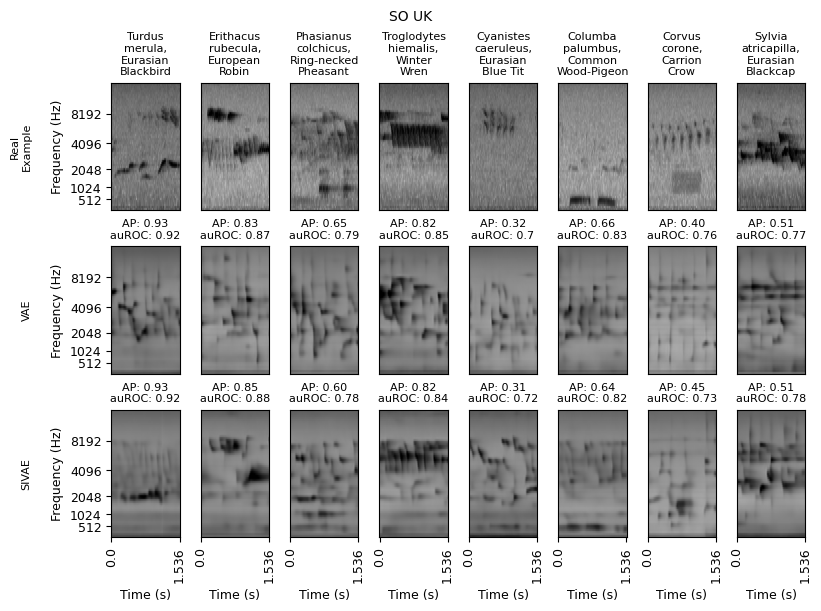

In [66]:
species_params = [ 
    { "species_name": "Turdus merula_Eurasian Blackbird", "file_name": "train/data/PL-12_0_20150604_0345.wav", "t_start_seconds": 4.3},  
    { "species_name": "Erithacus rubecula_European Robin", "file_name": "train/data/BA-04_0_20150620_0515.wav", "t_start_seconds": 29},  
    { "species_name": "Phasianus colchicus_Ring-necked Pheasant", "file_name": "train/data/PL-03_0_20150605_0445.wav", "t_start_seconds": 29.5},  
    { "species_name": "Troglodytes hiemalis_Winter Wren", "file_name": "train/data/PL-11_0_20150605_0500.wav", "t_start_seconds": 45.2},  
    { "species_name": "Cyanistes caeruleus_Eurasian Blue Tit", "file_name": "train/data/PL-12_0_20150604_0345.wav", "t_start_seconds": 47},  
    { "species_name": "Columba palumbus_Common Wood-Pigeon", "file_name": "train/data/BA-04_0_20150620_0615.wav", "t_start_seconds": 24.2},  
    { "species_name": "Corvus corone_Carrion Crow", "file_name": "train/data/BA-01_0_20150621_0445.wav", "t_start_seconds": 32.6},
    { "species_name": "Sylvia atricapilla_Eurasian Blackcap", "file_name": "train/data/PL-11_0_20150603_0645.wav", "t_start_seconds": 19},

]
for params in species_params:
    counts = data.metadata.merge(
        data.labels.astype(bool).astype(int),
        left_index=True,
        right_index=True
    ).groupby("habitat")[params["species_name"]].sum().reset_index()
    params["habitat"] = counts.loc[counts[params["species_name"]].idxmax()].habitat

fig, axes = plt.subplots(
    nrows=3,
    ncols=len(species_params) + 1,
    figsize=(8.1, 6),
    width_ratios=[0.01, *[0.95 / (len(species_params)) for _ in range(len(species_params))]],
    constrained_layout=True,
)
vmax, vmin = 0.0, -80
hops_per_second = 48_000 / 384
frame_length_seconds = 192 / hops_per_second
frame_length_hops = 192

model_habitat_means = {}
for j, (model_name, vae, clf) in enumerate([(vae_model_name, vae, vae_clf), (sivae_model_name, sivae, sivae_clf)]):
    dm = SoundscapeEmbeddingsDataModule(root=f"/its/home/kag25/data/soundscape_vae_embeddings/{model_name}/SO_UK").setup()
    embeddings = dm.train_data
    features = embeddings.features
    labels = embeddings.labels.reset_index()
    labels = labels.merge(data.metadata.loc[data.metadata.index.isin(labels.file_i), ["file_name", "habitat"]], on='file_i', how="inner")
    z_mean = embeddings.features[[f"z_mean_{i}" for i in range(128)]].merge(labels[["file_i", "habitat"]], on="file_i", how="left").drop("file_i", axis=1).groupby("habitat").mean()
    habitat_means = {habitat: torch.tensor(z_mean.loc[habitat], dtype=torch.float32, device="cuda").unsqueeze(0).unsqueeze(0) for habitat in z_mean.index}
    model_habitat_means[j] = habitat_means

model_params = {
    "vae": {
        "Turdus merula_Eurasian Blackbird": {"delta": 10, "shift": 0.0},
        "Erithacus rubecula_European Robin": {"delta": 15, "shift": 0.0},
        "Phasianus colchicus_Ring-necked Pheasant": {"delta": 15, "shift": -0.0},
        "Troglodytes hiemalis_Winter Wren": {"delta": 15, "shift": -0.0},
        "Cyanistes caeruleus_Eurasian Blue Tit": {"delta": 15, "shift": -0.0},
        "Columba palumbus_Common Wood-Pigeon": {"delta": 10, "shift": -0.0},
        "Corvus corone_Carrion Crow": {"delta": 35, "shift": 0.0},
        "Sylvia atricapilla_Eurasian Blackcap": {"delta": 15, "shift": 0.0},
    },
    "sivae": {
        "Turdus merula_Eurasian Blackbird": {"delta": 6, "shift": 0.5},
        "Erithacus rubecula_European Robin": {"delta": 15, "shift": 0.0},
        "Phasianus colchicus_Ring-necked Pheasant": {"delta": 15, "shift": -0.0},
        "Troglodytes hiemalis_Winter Wren": {"delta": 15, "shift": -0.0},
        "Cyanistes caeruleus_Eurasian Blue Tit": {"delta": 15, "shift": -0.0},
        "Columba palumbus_Common Wood-Pigeon": {"delta": 10, "shift": -0.0},
        "Corvus corone_Carrion Crow": {"delta": 25, "shift": 0.0},
        "Sylvia atricapilla_Eurasian Blackcap": {"delta": 15, "shift": 0.0},
    },
}
with torch.no_grad():
    for i, params in enumerate(species_params):
        species_name, file_name, t_start_seconds, habitat = params.values()
        if i == 0:
            title_ax = axes[0, 0]
            title_ax.set_ylabel("Real\nExample", fontsize=plt.rcParams['axes.titlesize'])
            make_ax_invisible(title_ax)
            title_ax = axes[1, 0]
            title_ax.set_ylabel("VAE", fontsize=plt.rcParams['axes.titlesize'])
            make_ax_invisible(title_ax)
            title_ax = axes[2, 0]
            title_ax.set_ylabel("SIVAE", fontsize=plt.rcParams['axes.titlesize'])
            make_ax_invisible(title_ax)

        ax = axes[0, i + 1]
        ax.set_title(wrap_sentence(species_name.replace("_", ", "), 10))
        t_start = int(t_start_seconds * hops_per_second)
        t_end = t_start + int(frame_length_seconds * hops_per_second)
        x = vae.front_end(data.load_sample(data.base_dir / file_name).unsqueeze(0).to("cuda")).squeeze()
        x_db = 20 * np.log10(x[:, t_start:t_end].exp().cpu())
        # plot the original
        vae.front_end.plot(x_db, vmax=vmax, vmin=vmin, ax=ax, cmap="Greys")
        ax.tick_params(labelbottom=False, bottom=False)
        ax.set_xlabel("")
        
        for j, (model_class, vae, clf, scores) in enumerate([("vae", vae, vae_clf, vae_scores), ("sivae", sivae, sivae_clf, sivae_scores)]):
            delta, shift = model_params[model_class][species_name].values()
            ap, auroc = scores[(scores.species_name == species_name)][["AP", "auROC"]].iloc[0].to_dict().values()
            z = model_habitat_means[j][habitat]
            W = clf.species_weights(species_name)
            norm = torch.linalg.norm(W)
            z_tilde = z + ((z @ W.T / norm) + delta) * (W / norm)
            x_tilde = vae.decode(z_tilde, shift * torch.ones(1, 1, 1, device=z.device)).cpu().squeeze().t()
            x_tilde_db = 20 * np.log10(x_tilde.exp())
            ax = axes[j + 1, i + 1]
            vae.front_end.plot(x_tilde_db, vmax=vmax, vmin=vmin, cmap="Greys", ax=ax)
            ax.tick_params(labelbottom=False, bottom=False)
            ax.set_xlabel("")
            ax.set_title(f"AP: {np.format_float_positional(ap, precision=2)}\nauROC: {np.format_float_positional(auroc, precision=2)}")
            
for ax in axes[:, 2:].flatten():
    ax.set_ylabel("")
    ax.tick_params(labelleft=False, left=False)

for ax in axes[-1, 1:].flatten():
    ax.tick_params(labelbottom=True, bottom=True)
    ax.set_xticks([0, 191], [0.0, 1.536], rotation=90)
    ax.set_xlabel("Time (s)")

fig.suptitle("SO UK")
fig.savefig(save_dir / "so_uk_interpolation.pdf", format="pdf")
plt.show()

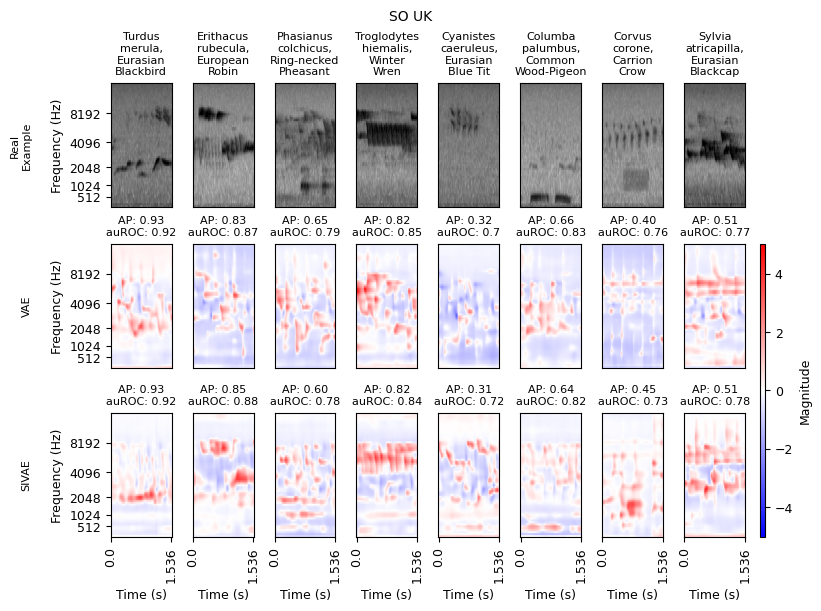

In [67]:
species_params = [ 
    { "species_name": "Turdus merula_Eurasian Blackbird", "file_name": "train/data/PL-12_0_20150604_0345.wav", "t_start_seconds": 4.3},  
    { "species_name": "Erithacus rubecula_European Robin", "file_name": "train/data/BA-04_0_20150620_0515.wav", "t_start_seconds": 29},  
    { "species_name": "Phasianus colchicus_Ring-necked Pheasant", "file_name": "train/data/PL-03_0_20150605_0445.wav", "t_start_seconds": 29.5},  
    { "species_name": "Troglodytes hiemalis_Winter Wren", "file_name": "train/data/PL-11_0_20150605_0500.wav", "t_start_seconds": 45.2},  
    { "species_name": "Cyanistes caeruleus_Eurasian Blue Tit", "file_name": "train/data/PL-12_0_20150604_0345.wav", "t_start_seconds": 47},  
    { "species_name": "Columba palumbus_Common Wood-Pigeon", "file_name": "train/data/BA-04_0_20150620_0615.wav", "t_start_seconds": 24.2},  
    { "species_name": "Corvus corone_Carrion Crow", "file_name": "train/data/BA-01_0_20150621_0445.wav", "t_start_seconds": 32.6},
    { "species_name": "Sylvia atricapilla_Eurasian Blackcap", "file_name": "train/data/PL-11_0_20150603_0645.wav", "t_start_seconds": 19},

]
for params in species_params:
    counts = data.metadata.merge(
        data.labels.astype(bool).astype(int),
        left_index=True,
        right_index=True
    ).groupby("habitat")[params["species_name"]].sum().reset_index()
    params["habitat"] = counts.loc[counts[params["species_name"]].idxmax()].habitat

fig = plt.figure(figsize=(8.1, 6), constrained_layout=True)
gs = fig.add_gridspec(nrows=3, ncols=len(species_params) + 2, width_ratios=[0.01,*[0.95 / len(species_params) for _ in range(len(species_params))], 0.01,])
axes = np.empty((3, len(species_params) + 2), dtype=object)
for r in range(3):
    for c in range(len(species_params) + 1):
        axes[r, c] = fig.add_subplot(gs[r, c])
axes[0, -1] = fig.add_subplot(gs[0, -1])
axes[0, -1].set_visible(False)
axes[1, -1] = fig.add_subplot(gs[1:, -1])
axes[2, -1] = axes[1, -1]

vmax, vmin = 0.0, -80
hops_per_second = 48_000 / 384
frame_length_seconds = 192 / hops_per_second
frame_length_hops = 192

model_habitat_means = {}
for j, (model_name, vae, clf) in enumerate([(vae_model_name, vae, vae_clf), (sivae_model_name, sivae, sivae_clf)]):
    dm = SoundscapeEmbeddingsDataModule(root=f"/its/home/kag25/data/soundscape_vae_embeddings/{model_name}/SO_UK").setup()
    embeddings = dm.train_data
    features = embeddings.features
    labels = embeddings.labels.reset_index()
    labels = labels.merge(data.metadata.loc[data.metadata.index.isin(labels.file_i), ["file_name", "habitat"]], on='file_i', how="inner")
    z_mean = embeddings.features[[f"z_mean_{i}" for i in range(128)]].merge(labels[["file_i", "habitat"]], on="file_i", how="left").drop("file_i", axis=1).groupby("habitat").mean()
    habitat_means = {habitat: torch.tensor(z_mean.loc[habitat], dtype=torch.float32, device="cuda").unsqueeze(0).unsqueeze(0) for habitat in z_mean.index}
    model_habitat_means[j] = habitat_means

model_params = {
    "vae": {
        "Turdus merula_Eurasian Blackbird": {"delta": 10, "shift": 0.0},
        "Erithacus rubecula_European Robin": {"delta": 15, "shift": 0.0},
        "Phasianus colchicus_Ring-necked Pheasant": {"delta": 15, "shift": -0.0},
        "Troglodytes hiemalis_Winter Wren": {"delta": 15, "shift": -0.0},
        "Cyanistes caeruleus_Eurasian Blue Tit": {"delta": 15, "shift": -0.0},
        "Columba palumbus_Common Wood-Pigeon": {"delta": 10, "shift": -0.0},
        "Corvus corone_Carrion Crow": {"delta": 35, "shift": 0.0},
        "Sylvia atricapilla_Eurasian Blackcap": {"delta": 15, "shift": 0.0},
    },
    "sivae": {
        "Turdus merula_Eurasian Blackbird": {"delta": 6, "shift": 0.5},
        "Erithacus rubecula_European Robin": {"delta": 15, "shift": 0.0},
        "Phasianus colchicus_Ring-necked Pheasant": {"delta": 15, "shift": -0.0},
        "Troglodytes hiemalis_Winter Wren": {"delta": 15, "shift": -0.0},
        "Cyanistes caeruleus_Eurasian Blue Tit": {"delta": 15, "shift": -0.0},
        "Columba palumbus_Common Wood-Pigeon": {"delta": 10, "shift": -0.0},
        "Corvus corone_Carrion Crow": {"delta": 25, "shift": 0.0},
        "Sylvia atricapilla_Eurasian Blackcap": {"delta": 15, "shift": 0.0},
    },
}
residuals = []
rmin, rmax = np.inf, -np.inf

with torch.no_grad():
    for i, params in enumerate(species_params):
        species_residuals = []
        species_name, file_name, t_start_seconds, habitat = params.values()
        if i == 0:
            title_ax = axes[0, 0]
            title_ax.set_ylabel("Real\nExample", fontsize=plt.rcParams['axes.titlesize'])
            make_ax_invisible(title_ax)
            title_ax = axes[1, 0]
            title_ax.set_ylabel("VAE", fontsize=plt.rcParams['axes.titlesize'])
            make_ax_invisible(title_ax)
            title_ax = axes[2, 0]
            title_ax.set_ylabel("SIVAE", fontsize=plt.rcParams['axes.titlesize'])
            make_ax_invisible(title_ax)

        ax = axes[0, i + 1]
        ax.set_title(wrap_sentence(species_name.replace("_", ", "), 10))
        t_start = int(t_start_seconds * hops_per_second)
        t_end = t_start + int(frame_length_seconds * hops_per_second)
        x = vae.front_end(data.load_sample(data.base_dir / file_name).unsqueeze(0).to("cuda")).squeeze()
        x_db = 20 * np.log10(x[:, t_start:t_end].exp().cpu())
        # plot the original
        vae.front_end.plot(x_db, vmax=vmax, vmin=vmin, ax=ax, cmap="Greys")
        ax.tick_params(labelbottom=False, bottom=False)
        ax.set_xlabel("")
        
        for j, (model_class, vae, clf, scores) in enumerate([("vae", vae, vae_clf, vae_scores), ("sivae", sivae, sivae_clf, sivae_scores)]):
            delta, shift = model_params[model_class][species_name].values()
            z = model_habitat_means[j][habitat]
            x0 =  vae.decode(z, torch.zeros(1, 1, 1, device=z.device)).cpu().squeeze().t()
            W = clf.species_weights(species_name)
            norm = torch.linalg.norm(W)
            z_tilde = z + ((z @ W.T / norm) + delta) * (W / norm)
            x_tilde = vae.decode(z_tilde, shift * torch.ones(1, 1, 1, device=z.device)).cpu().squeeze().t()
            # (x_tilde - x)
            # x_tilde_db = 20 * np.log10(x_tilde.exp())
            x_res = (x_tilde - x0)
            rmin = min(rmin, x_res.min())
            rmax = max(rmax, x_res.max())
            species_residuals.append(x_res)
        residuals.append(species_residuals)

for i, params in enumerate(species_params):
    species_name, file_name, t_start_seconds, habitat = params.values()
    for j, (model_class, vae, clf, scores) in enumerate([("vae", vae, vae_clf, vae_scores), ("sivae", sivae, sivae_clf, sivae_scores)]):
        ax = axes[j + 1, i + 1]
        ap, auroc = scores[scores.species_name == species_name][["AP", "auROC"]].iloc[0].to_dict().values()
        residual = residuals[i][j]
        bound = max(np.abs(rmin), np.abs(rmax))
        mesh = vae.front_end.plot(residual, cmap="bwr", vmin=-bound, vmax=bound, ax=ax)
        ax.tick_params(labelbottom=False, bottom=False)
        ax.set_xlabel("")
        ax.set_title(f"AP: {np.format_float_positional(ap, precision=2)}\nauROC: {np.format_float_positional(auroc, precision=2)}")
            
for ax in axes[:, 2:-1].flatten():
    ax.set_ylabel("")
    ax.tick_params(labelleft=False, left=False)

for ax in axes[-1, 1:-1].flatten():
    ax.tick_params(labelbottom=True, bottom=True)
    ax.set_xticks([0, 191], [0.0, 1.536], rotation=90)
    ax.set_xlabel("Time (s)")

cbar = fig.colorbar(mesh, cax=axes[1, -1])
cbar.set_label("Magnitude")
fig.suptitle("SO UK")
fig.savefig(save_dir / "so_uk_interpolation_residual.pdf", format="pdf")
plt.show()